In [2]:
import pandas as pd
dataset = pd.read_csv('insurance_pre.csv')
dataset

,age,sex,bmi,children,smoker,charges
0,19,female,27.900,0,yes,16884.92400
1,18,male,33.770,1,no,1725.55230
2,28,male,33.000,3,no,4449.46200
3,33,male,22.705,0,no,21984.47061
4,32,male,28.880,0,no,3866.85520
...,...,...,...,...,...,...
1333,50,male,30.970,3,no,10600.54830
1334,18,female,31.920,0,no,2205.98080
1335,18,female,36.850,0,no,1629.83350
1336,21,female,25.800,0,no,2007.94500


In [3]:
dataset = pd.get_dummies(dataset)
dataset

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes
0,19,27.900,0,16884.92400,True,False,False,True
1,18,33.770,1,1725.55230,False,True,True,False
2,28,33.000,3,4449.46200,False,True,True,False
3,33,22.705,0,21984.47061,False,True,True,False
4,32,28.880,0,3866.85520,False,True,True,False
...,...,...,...,...,...,...,...,...
1333,50,30.970,3,10600.54830,False,True,True,False
1334,18,31.920,0,2205.98080,True,False,True,False
1335,18,36.850,0,1629.83350,True,False,True,False
1336,21,25.800,0,2007.94500,True,False,True,False


In [4]:
independent = dataset[['age','bmi','children','sex_male','sex_female','smoker_no','smoker_yes']]
independent

,age,bmi,children,sex_male,sex_female,smoker_no,smoker_yes
0,19,27.900,0,False,True,False,True
1,18,33.770,1,True,False,True,False
2,28,33.000,3,True,False,True,False
3,33,22.705,0,True,False,True,False
4,32,28.880,0,True,False,True,False
...,...,...,...,...,...,...,...
1333,50,30.970,3,True,False,True,False
1334,18,31.920,0,False,True,True,False
1335,18,36.850,0,False,True,True,False
1336,21,25.800,0,False,True,True,False


In [5]:
dependent = dataset[['charges']]
dependent

,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520
...,...
1333,10600.54830
1334,2205.98080
1335,1629.83350
1336,2007.94500


In [7]:
from sklearn.model_selection import train_test_split
x_train,x_test, y_train, y_test = train_test_split(independent, dependent, test_size=0.3, random_state=0)
x_train,x_test,y_train,y_test

(      age     bmi  children  sex_male  sex_female  smoker_no  smoker_yes
 1163   18  28.215         0     False        True       True       False
 196    39  32.800         0     False        True       True       False
 438    52  46.750         5     False        True       True       False
 183    44  26.410         0     False        True       True       False
 1298   33  27.455         2      True       False       True       False
 ...   ...     ...       ...       ...         ...        ...         ...
 763    27  26.030         0      True       False       True       False
 835    42  35.970         2      True       False       True       False
 1216   40  25.080         0      True       False       True       False
 559    19  35.530         0      True       False       True       False
 684    33  18.500         1     False        True       True       False
 
 [936 rows x 7 columns],
       age     bmi  children  sex_male  sex_female  smoker_no  smoker_yes
 578    52 

In [8]:
# param_grid = {
#     'criterion': ['squared_error', 'friedman_mse', 'absolute_error'],
#     'max_depth': [None, 5, 10, 20],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4],
#     'max_features': [None, 'sqrt', 'log2'],
#     'splitter': ['best', 'random']
# }

In [55]:
from sklearn.tree import DecisionTreeRegressor
regressor = DecisionTreeRegressor(criterion='absolute_error',splitter='random',max_features='log2')
regressor.fit(x_train,y_train)

DecisionTreeRegressor(criterion='absolute_error', max_features='log2',
                      splitter='random')

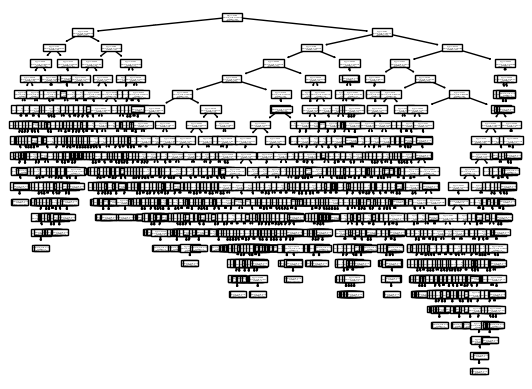

In [56]:
import matplotlib.pyplot as plt
from sklearn import tree
tree.plot_tree(regressor)
plt.show()

In [57]:
y_pred = regressor.predict(x_test)

In [58]:
from sklearn.metrics import r2_score
r_score = r2_score(y_test, y_pred)
r_score

0.7480169073545107